# Activation Functions

This notebook visualizes common activation functions and their derivatives, as discussed in the lecture.

Inspired by Hands-on ML with Scikit-Learn, Keras & TensorFlow, with corrections and improvements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

%matplotlib inline
plt.rc('axes',  labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

# Where to save the figures
IMAGES_PATH = os.path.join(".", "figs")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Activation functions

In [2]:
# --- Parameters ---
# For the logistic (sigmoid) function, a controls the steepness.
# We use a=1 (standard sigmoid) here to match PyTorch's torch.sigmoid.
# The lecture presents the general case with arbitrary a > 0.
a_logistic = 1.0

# Leaky ReLU slope for negative inputs
a_leaky = 0.2

# ELU alpha parameter
a_elu = 1.0

# SELU uses specific constants derived for self-normalization
lambda_selu = 1.0507009873554804934193349852946
alpha_selu   = 1.6732632423543772848170429916717

# --- Activation functions ---

def sigmoid(v):
    return 1 / (1 + np.exp(-a_logistic * v))

def relu(v):
    return np.maximum(0, v)

def leaky_relu(v):
    return np.where(v > 0, v, a_leaky * v)

def elu(v):
    return np.where(v > 0, v, a_elu * (np.exp(v) - 1))

def selu(v):
    return lambda_selu * np.where(v > 0, v, alpha_selu * (np.exp(v) - 1))

def softplus(v):
    return np.log1p(np.exp(v))

# --- Numerical derivative ---

def derivative(f, v, eps=1e-6):
    return (f(v + eps) - f(v - eps)) / (2 * eps)

Saving figure activation_functions_plot


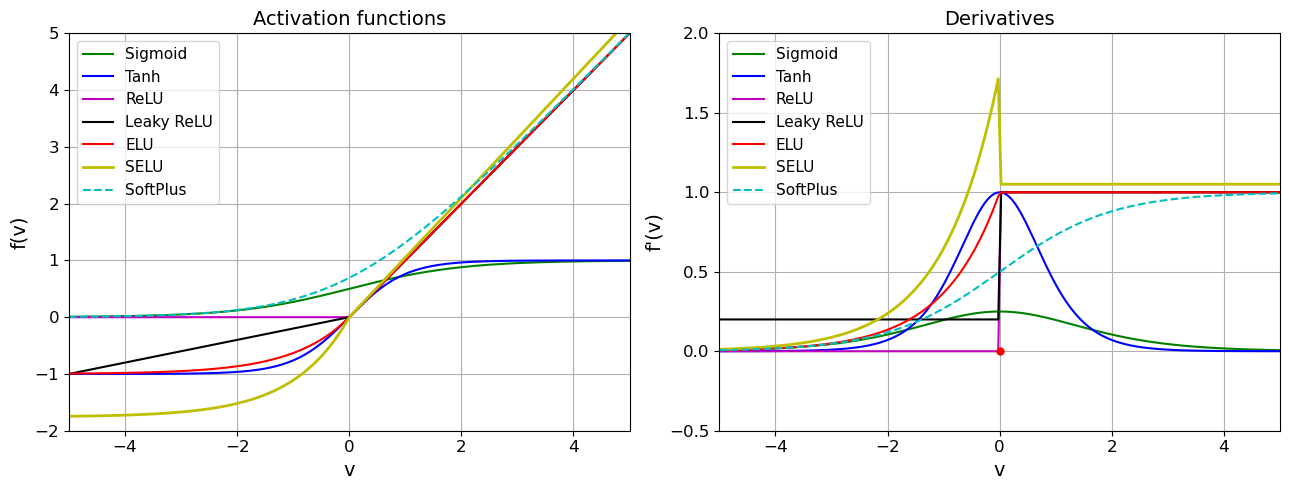

In [3]:
v = np.linspace(-5, 5, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Activation functions ---
ax1.plot(v, sigmoid(v),    "g-",  linewidth=1.5, label="Sigmoid")
ax1.plot(v, np.tanh(v),    "b-",  linewidth=1.5, label="Tanh")
ax1.plot(v, relu(v),       "m-",  linewidth=1.5, label="ReLU")
ax1.plot(v, leaky_relu(v), "k-",  linewidth=1.5, label="Leaky ReLU")
ax1.plot(v, elu(v),        "r-",  linewidth=1.5, label="ELU")
ax1.plot(v, selu(v),       "y-",  linewidth=2.0, label="SELU")
ax1.plot(v, softplus(v),   "c--", linewidth=1.5, label="SoftPlus")
ax1.grid(True)
ax1.legend(loc="upper left", fontsize=11)
ax1.set_title("Activation functions", fontsize=14)
ax1.set_xlabel("v")
ax1.set_ylabel("f(v)")
ax1.set_xlim(-5, 5)
ax1.set_ylim(-2, 5)

# --- Derivatives ---
ax2.plot(v, derivative(sigmoid, v),    "g-",  linewidth=1.5, label="Sigmoid")
ax2.plot(v, derivative(np.tanh, v),    "b-",  linewidth=1.5, label="Tanh")
ax2.plot(v, derivative(relu, v),       "m-",  linewidth=1.5, label="ReLU")
ax2.plot(v, derivative(leaky_relu, v), "k-",  linewidth=1.5, label="Leaky ReLU")
ax2.plot(v, derivative(elu, v),        "r-",  linewidth=1.5, label="ELU")
ax2.plot(v, derivative(selu, v),       "y-",  linewidth=2.0, label="SELU")
ax2.plot(v, derivative(softplus, v),   "c--", linewidth=1.5, label="SoftPlus")
ax2.plot(0, 0, "ro", markersize=5)  # ReLU non-differentiable point
ax2.grid(True)
ax2.legend(loc="upper left", fontsize=11)
ax2.set_title("Derivatives", fontsize=14)
ax2.set_xlabel("v")
ax2.set_ylabel("f'(v)")
ax2.set_xlim(-5, 5)
ax2.set_ylim(-0.5, 2.0)

save_fig("activation_functions_plot")
plt.show()